<a href="https://colab.research.google.com/github/amnaahsan96-maker/Fast-food-Restaurant-Sales-/blob/main/GastricCancer_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project: Machine Learning
# Title:“Gastric Cancer Detection using Random Forest Classifier”
## Model: "RandomForestClassifier"

**Introduction:This project focuses on detecting gastric cancer using machine learning. The dataset contains various features such as age, gender, and medical conditions. Data preprocessing techniques like handling missing values and encoding categorical variables were applied to prepare the data. A Random Forest Classifier was used to train the model and make predictions. The model’s performance was evaluated using accuracy and other metrics, making it useful for early detection and healthcare decision-making.**

# ** Submitted by:Bushra Shaukat**
# Submitted to: Sir Muhammad Ansar

**Importing labraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**The libraries pandas, numpy, and matplotlib.pyplot are imported to perform data analysis and visualization in the project. Pandas is used for handling and organizing the dataset, while NumPy supports numerical computations and array operations. Matplotlib is used to create graphs and visualizations to better understand the data.**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

**These libraries are used to split data into training and testing sets, build the Random Forest model, and evaluate its performance using accuracy and other metrics.**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
df= pd.read_csv("/content/drive/MyDrive/gastric_cancer_detection_dataset.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Connects Google Drive to Colab and Reads CSV file into a DataFrame (table)**

## **A- Data inpections**

**1-checking ist five rows**

In [ ]:
df.head()

,age,gender,ethnicity,geographical_location,family_history,smoking_habits,alcohol_consumption,helicobacter_pylori_infection,dietary_habits,existing_conditions,...,elmmo,microcosm,miranda,mirdb,pictar,pita,targetscan,predicted.sum,all.sum,label
0,43,Male,Ethnicity_A,Other,1,0,0,0,Low_Salt,Chronic Gastritis,...,0.187003,0.786422,0.204816,0.561920,0.438175,0.283603,0.928244,4.324299,7.666791,0
1,86,Female,Ethnicity_B,California,1,0,0,1,High_Salt,Diabetes,...,0.493322,0.963989,0.498041,0.985585,0.144609,0.375375,0.103573,7.967674,1.483280,0
2,68,Male,Ethnicity_A,California,0,1,1,0,High_Salt,NaN,...,0.573560,0.666896,0.540388,0.905853,0.827279,0.350915,0.166878,3.748651,3.046783,0
3,57,Female,Ethnicity_A,Other,0,0,0,1,High_Salt,Chronic Gastritis,...,0.261399,0.949488,0.134170,0.429935,0.935231,0.794704,0.867036,5.478298,8.811307,0
4,33,Male,Ethnicity_A,California,0,1,1,0,High_Salt,Diabetes,...,0.754478,0.263164,0.876767,0.650832,0.337669,0.427492,0.915804,1.809181,0.394632,0


The dataset consists of 29 features that are categorized into different groups including patient demographics, lifestyle risk factors, biological/genomic indicators, and computed scores. The demographic features such as age, gender, ethnicity, and geographical location provide basic information about the patient. The risk factor features include family history, smoking habits, alcohol consumption, Helicobacter pylori infection, dietary habits, and existing medical conditions, which help in identifying potential cancer risks. The dataset also contains advanced biological and genomic features such as elmmo, microcosm, miranda, mirdb, pictar, pita, and targetscan, which represent gene expression and molecular interaction scores used for deeper cancer analysis. In addition, computed features like predicted.sum and all.sum summarize overall biological predictions. The final target variable, label, indicates whether the patient is diagnosed with gastric cancer or not, where 0 represents non-cancer and 1 represents cancer. Overall, the dataset combines clinical, lifestyle, and biological data to support accurate machine learning-based cancer prediction.

**2-checking last five rows**

In [ ]:
df.tail()

,age,gender,ethnicity,geographical_location,family_history,smoking_habits,alcohol_consumption,helicobacter_pylori_infection,dietary_habits,existing_conditions,...,elmmo,microcosm,miranda,mirdb,pictar,pita,targetscan,predicted.sum,all.sum,label
212349,47,Male,Ethnicity_A,California,0,1,1,0,High_Salt,Chronic Gastritis,...,0.408123,0.925035,0.267628,0.538474,0.463471,0.827892,0.929147,0.866260,6.698303,0
212350,59,Female,Ethnicity_A,California,0,1,1,0,High_Salt,Chronic Gastritis,...,0.578204,0.768279,0.339168,0.236523,0.444216,0.011762,0.053098,5.102216,2.338017,0
212351,58,Female,Ethnicity_C,California,0,0,0,0,High_Salt,NaN,...,0.940936,0.865221,0.448189,0.899351,0.766615,0.098454,0.384019,7.774612,4.601637,1
212352,77,Female,Ethnicity_B,California,1,1,0,1,High_Salt,Chronic Gastritis,...,0.498088,0.048195,0.924610,0.101521,0.464988,0.639401,0.410327,2.362698,2.020047,0
212353,71,Male,Ethnicity_A,California,0,0,0,1,High_Salt,NaN,...,0.689696,0.701524,0.250955,0.102458,0.077025,0.463766,0.765164,2.392974,4.487878,0


**3-checking details**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 212354 entries, 0 to 212353
Data columns (total 29 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   age                            212354 non-null  int64  
 1   gender                         212354 non-null  object 
 2   ethnicity                      212354 non-null  object 
 3   geographical_location          212354 non-null  object 
 4   family_history                 212354 non-null  int64  
 5   smoking_habits                 212354 non-null  int64  
 6   alcohol_consumption            212354 non-null  int64  
 7   helicobacter_pylori_infection  212354 non-null  int64  
 8   dietary_habits                 212354 non-null  object 
 9   existing_conditions            169868 non-null  object 
 10  endoscopic_images              212354 non-null  object 
 11  biopsy_results                 212354 non-null  object 
 12  ct_scan                       

4.Categorical Data Encoding (One-Hot Encoding)

In [ ]:
df_encoded = pd.get_dummies(df, drop_first=True)

**This code converts categorical (text) data into numerical (0/1) format and removes one category to avoid redundancy, making the dataset suitable for machine learning models.**

**5.Checking Rows and Coloumns:**

In [ ]:
df.shape

(212354, 29)

**5.Column Names**

In [ ]:
df.columns

Index(['age', 'gender', 'ethnicity', 'geographical_location', 'family_history',
       'smoking_habits', 'alcohol_consumption',
       'helicobacter_pylori_infection', 'dietary_habits',
       'existing_conditions', 'endoscopic_images', 'biopsy_results', 'ct_scan',
       'mature_mirna_acc', 'mature_mirna_id', 'target_symbol', 'target_entrez',
       'target_ensembl', 'diana_microt', 'elmmo', 'microcosm', 'miranda',
       'mirdb', 'pictar', 'pita', 'targetscan', 'predicted.sum', 'all.sum',
       'label'],
      dtype='object')

**7.Data Types for Preprocessing**

In [ ]:
df.dtypes

,0
age,int64
gender,object
ethnicity,object
geographical_location,object
family_history,int64
smoking_habits,int64
alcohol_consumption,int64
helicobacter_pylori_infection,int64
dietary_habits,object
existing_conditions,object


**Removing Unnecessary Column**

In [ ]:
df.drop(columns=['Unnamed: 0'], errors='ignore', inplace=True)

**This code removes the unwanted column (Unnamed: 0) from the dataset to clean the data and avoid irrelevant information in the model.**

**Frequency Distribution of Values using value_counts()**

In [ ]:
df["label"].value_counts()

,count
label,
0,191395
1,20959


**Label-based Data Selection (row and column)**

In [ ]:
df.loc[5]

,5
age,33
gender,Female
ethnicity,Ethnicity_C
geographical_location,California
family_history,1
smoking_habits,0
alcohol_consumption,1
helicobacter_pylori_infection,0
dietary_habits,High_Salt
existing_conditions,Chronic Gastritis


**Index-based Data Selection (row and column)**

In [ ]:
df.iloc[:, [1,5,6]]

,gender,smoking_habits,alcohol_consumption
0,Male,0,0
1,Female,0,0
2,Male,1,1
3,Female,0,0
4,Male,1,1
...,...,...,...
212349,Male,1,1
212350,Female,1,1
212351,Female,0,0
212352,Female,1,0


**Applying mathematical fuctions**

In [ ]:
df.describe()

,age,family_history,smoking_habits,alcohol_consumption,helicobacter_pylori_infection,target_entrez,target_ensembl,diana_microt,elmmo,microcosm,miranda,mirdb,pictar,pita,targetscan,predicted.sum,all.sum,label
count,212354.000000,212354.000000,212354.000000,212354.000000,212354.000000,212354.000000,2.123540e+05,212354.000000,2.123540e+05,212354.000000,212354.000000,212354.000000,2.123540e+05,212354.000000,212354.000000,212354.000000,212354.000000,212354.000000
mean,53.258036,0.300564,0.399154,0.499378,0.249470,5496.117332,1.499874e+06,0.500527,4.994971e-01,0.500083,0.499895,0.500125,4.989745e-01,0.501152,0.501117,5.010346,5.000085,0.098698
std,18.984419,0.458504,0.489726,0.500001,0.432707,2596.817632,2.882585e+05,0.288757,2.888452e-01,0.288491,0.288571,0.288738,2.884995e-01,0.288874,0.288678,2.884461,2.882685,0.298257
min,20.000000,0.000000,0.000000,0.000000,0.000000,1000.000000,1.000007e+06,0.000005,6.089062e-07,0.000003,0.000001,0.000013,7.743957e-07,0.000008,0.000004,0.000016,0.000081,0.000000
25%,37.000000,0.000000,0.000000,0.000000,0.000000,3252.000000,1.251177e+06,0.250034,2.486468e-01,0.249877,0.250206,0.250293,2.497943e-01,0.250322,0.251790,2.512241,2.505941,0.000000
50%,50.000000,0.000000,0.000000,0.000000,0.000000,5491.000000,1.500324e+06,0.501302,4.998040e-01,0.500498,0.499635,0.499888,4.985230e-01,0.502228,0.501814,5.018196,5.003598,0.000000
75%,69.000000,1.000000,1.000000,1.000000,0.000000,7738.000000,1.748424e+06,0.750783,7.495843e-01,0.748769,0.749075,0.749994,7.487212e-01,0.751212,0.751860,7.508878,7.493106,0.000000
max,89.000000,1.000000,1.000000,1.000000,1.000000,9999.000000,1.999998e+06,0.999998,9.999993e-01,0.999997,0.999997,1.000000,9.999986e-01,0.999993,0.999997,9.999908,9.999987,1.000000


# B-Data Cleaning

**1-checking Missing Values**

In [ ]:
df.isnull()

,age,gender,ethnicity,geographical_location,family_history,smoking_habits,alcohol_consumption,helicobacter_pylori_infection,dietary_habits,existing_conditions,...,elmmo,microcosm,miranda,mirdb,pictar,pita,targetscan,predicted.sum,all.sum,label
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212349,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
212350,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
212351,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
212352,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
df.isnull().sum()

,0
age,0
gender,0
ethnicity,0
geographical_location,0
family_history,0
smoking_habits,0
alcohol_consumption,0
helicobacter_pylori_infection,0
dietary_habits,0
existing_conditions,42486


2**."Non-Null Values in Dataset"**

In [ ]:
df.notnull()

,age,gender,ethnicity,geographical_location,family_history,smoking_habits,alcohol_consumption,helicobacter_pylori_infection,dietary_habits,existing_conditions,...,elmmo,microcosm,miranda,mirdb,pictar,pita,targetscan,predicted.sum,all.sum,label
0,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
1,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
2,True,True,True,True,True,True,True,True,True,False,...,True,True,True,True,True,True,True,True,True,True
3,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
4,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212349,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
212350,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
212351,True,True,True,True,True,True,True,True,True,False,...,True,True,True,True,True,True,True,True,True,True
212352,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True


In [ ]:
df.notnull().sum()

,0
age,212354
gender,212354
ethnicity,212354
geographical_location,212354
family_history,212354
smoking_habits,212354
alcohol_consumption,212354
helicobacter_pylori_infection,212354
dietary_habits,212354
existing_conditions,169868


**4.Fill Missing Values**

In [ ]:
df.interpolate()

/tmp/ipykernel_17642/4002874584.py:1: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df.interpolate()


,age,gender,ethnicity,geographical_location,family_history,smoking_habits,alcohol_consumption,helicobacter_pylori_infection,dietary_habits,existing_conditions,...,elmmo,microcosm,miranda,mirdb,pictar,pita,targetscan,predicted.sum,all.sum,label
0,43,Male,Ethnicity_A,Other,1,0,0,0,Low_Salt,Chronic Gastritis,...,0.187003,0.786422,0.204816,0.561920,0.438175,0.283603,0.928244,4.324299,7.666791,0
1,86,Female,Ethnicity_B,California,1,0,0,1,High_Salt,Diabetes,...,0.493322,0.963989,0.498041,0.985585,0.144609,0.375375,0.103573,7.967674,1.483280,0
2,68,Male,Ethnicity_A,California,0,1,1,0,High_Salt,NaN,...,0.573560,0.666896,0.540388,0.905853,0.827279,0.350915,0.166878,3.748651,3.046783,0
3,57,Female,Ethnicity_A,Other,0,0,0,1,High_Salt,Chronic Gastritis,...,0.261399,0.949488,0.134170,0.429935,0.935231,0.794704,0.867036,5.478298,8.811307,0
4,33,Male,Ethnicity_A,California,0,1,1,0,High_Salt,Diabetes,...,0.754478,0.263164,0.876767,0.650832,0.337669,0.427492,0.915804,1.809181,0.394632,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212349,47,Male,Ethnicity_A,California,0,1,1,0,High_Salt,Chronic Gastritis,...,0.408123,0.925035,0.267628,0.538474,0.463471,0.827892,0.929147,0.866260,6.698303,0
212350,59,Female,Ethnicity_A,California,0,1,1,0,High_Salt,Chronic Gastritis,...,0.578204,0.768279,0.339168,0.236523,0.444216,0.011762,0.053098,5.102216,2.338017,0
212351,58,Female,Ethnicity_C,California,0,0,0,0,High_Salt,NaN,...,0.940936,0.865221,0.448189,0.899351,0.766615,0.098454,0.384019,7.774612,4.601637,1
212352,77,Female,Ethnicity_B,California,1,1,0,1,High_Salt,Chronic Gastritis,...,0.498088,0.048195,0.924610,0.101521,0.464988,0.639401,0.410327,2.362698,2.020047,0


**3.Remove Missing Values**

In [ ]:
df.dropna()

,age,gender,ethnicity,geographical_location,family_history,smoking_habits,alcohol_consumption,helicobacter_pylori_infection,dietary_habits,existing_conditions,...,elmmo,microcosm,miranda,mirdb,pictar,pita,targetscan,predicted.sum,all.sum,label
0,43,Male,Ethnicity_A,Other,1,0,0,0,Low_Salt,Chronic Gastritis,...,0.187003,0.786422,0.204816,0.561920,0.438175,0.283603,0.928244,4.324299,7.666791,0
1,86,Female,Ethnicity_B,California,1,0,0,1,High_Salt,Diabetes,...,0.493322,0.963989,0.498041,0.985585,0.144609,0.375375,0.103573,7.967674,1.483280,0
3,57,Female,Ethnicity_A,Other,0,0,0,1,High_Salt,Chronic Gastritis,...,0.261399,0.949488,0.134170,0.429935,0.935231,0.794704,0.867036,5.478298,8.811307,0
4,33,Male,Ethnicity_A,California,0,1,1,0,High_Salt,Diabetes,...,0.754478,0.263164,0.876767,0.650832,0.337669,0.427492,0.915804,1.809181,0.394632,0
5,33,Female,Ethnicity_C,California,1,0,1,0,High_Salt,Chronic Gastritis,...,0.050714,0.954498,0.928561,0.349869,0.768395,0.357806,0.464772,4.470495,8.478575,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212347,27,Male,Ethnicity_A,Other,0,0,1,1,High_Salt,Chronic Gastritis,...,0.450773,0.545828,0.739607,0.929764,0.131652,0.880751,0.134566,3.610328,8.253089,0
212348,49,Female,Ethnicity_C,California,0,1,1,1,High_Salt,Chronic Gastritis,...,0.713226,0.432300,0.507213,0.689894,0.998506,0.569885,0.978047,2.795402,3.935588,0
212349,47,Male,Ethnicity_A,California,0,1,1,0,High_Salt,Chronic Gastritis,...,0.408123,0.925035,0.267628,0.538474,0.463471,0.827892,0.929147,0.866260,6.698303,0
212350,59,Female,Ethnicity_A,California,0,1,1,0,High_Salt,Chronic Gastritis,...,0.578204,0.768279,0.339168,0.236523,0.444216,0.011762,0.053098,5.102216,2.338017,0


**Handling Missing Value**s

In [ ]:
df.fillna(0, inplace=True)

**This code replaces all missing values (NaN) in the dataset with 0 to ensure clean and complete data for model training.**

**5.Checking Duplicate Records**

In [ ]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
212349,False
212350,False
212351,False
212352,False


**6.Removing Duplicate Records**

In [ ]:
df.drop_duplicates()

,age,gender,ethnicity,geographical_location,family_history,smoking_habits,alcohol_consumption,helicobacter_pylori_infection,dietary_habits,existing_conditions,...,elmmo,microcosm,miranda,mirdb,pictar,pita,targetscan,predicted.sum,all.sum,label
0,43,Male,Ethnicity_A,Other,1,0,0,0,Low_Salt,Chronic Gastritis,...,0.187003,0.786422,0.204816,0.561920,0.438175,0.283603,0.928244,4.324299,7.666791,0
1,86,Female,Ethnicity_B,California,1,0,0,1,High_Salt,Diabetes,...,0.493322,0.963989,0.498041,0.985585,0.144609,0.375375,0.103573,7.967674,1.483280,0
2,68,Male,Ethnicity_A,California,0,1,1,0,High_Salt,0,...,0.573560,0.666896,0.540388,0.905853,0.827279,0.350915,0.166878,3.748651,3.046783,0
3,57,Female,Ethnicity_A,Other,0,0,0,1,High_Salt,Chronic Gastritis,...,0.261399,0.949488,0.134170,0.429935,0.935231,0.794704,0.867036,5.478298,8.811307,0
4,33,Male,Ethnicity_A,California,0,1,1,0,High_Salt,Diabetes,...,0.754478,0.263164,0.876767,0.650832,0.337669,0.427492,0.915804,1.809181,0.394632,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212349,47,Male,Ethnicity_A,California,0,1,1,0,High_Salt,Chronic Gastritis,...,0.408123,0.925035,0.267628,0.538474,0.463471,0.827892,0.929147,0.866260,6.698303,0
212350,59,Female,Ethnicity_A,California,0,1,1,0,High_Salt,Chronic Gastritis,...,0.578204,0.768279,0.339168,0.236523,0.444216,0.011762,0.053098,5.102216,2.338017,0
212351,58,Female,Ethnicity_C,California,0,0,0,0,High_Salt,0,...,0.940936,0.865221,0.448189,0.899351,0.766615,0.098454,0.384019,7.774612,4.601637,1
212352,77,Female,Ethnicity_B,California,1,1,0,1,High_Salt,Chronic Gastritis,...,0.498088,0.048195,0.924610,0.101521,0.464988,0.639401,0.410327,2.362698,2.020047,0


*6.Removing Duplicate Records**

In [ ]:
df.drop_duplicates()

,age,gender,ethnicity,geographical_location,family_history,smoking_habits,alcohol_consumption,helicobacter_pylori_infection,dietary_habits,existing_conditions,...,elmmo,microcosm,miranda,mirdb,pictar,pita,targetscan,predicted.sum,all.sum,label
0,43,Male,Ethnicity_A,Other,1,0,0,0,Low_Salt,Chronic Gastritis,...,0.187003,0.786422,0.204816,0.561920,0.438175,0.283603,0.928244,4.324299,7.666791,0
1,86,Female,Ethnicity_B,California,1,0,0,1,High_Salt,Diabetes,...,0.493322,0.963989,0.498041,0.985585,0.144609,0.375375,0.103573,7.967674,1.483280,0
2,68,Male,Ethnicity_A,California,0,1,1,0,High_Salt,0,...,0.573560,0.666896,0.540388,0.905853,0.827279,0.350915,0.166878,3.748651,3.046783,0
3,57,Female,Ethnicity_A,Other,0,0,0,1,High_Salt,Chronic Gastritis,...,0.261399,0.949488,0.134170,0.429935,0.935231,0.794704,0.867036,5.478298,8.811307,0
4,33,Male,Ethnicity_A,California,0,1,1,0,High_Salt,Diabetes,...,0.754478,0.263164,0.876767,0.650832,0.337669,0.427492,0.915804,1.809181,0.394632,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212349,47,Male,Ethnicity_A,California,0,1,1,0,High_Salt,Chronic Gastritis,...,0.408123,0.925035,0.267628,0.538474,0.463471,0.827892,0.929147,0.866260,6.698303,0
212350,59,Female,Ethnicity_A,California,0,1,1,0,High_Salt,Chronic Gastritis,...,0.578204,0.768279,0.339168,0.236523,0.444216,0.011762,0.053098,5.102216,2.338017,0
212351,58,Female,Ethnicity_C,California,0,0,0,0,High_Salt,0,...,0.940936,0.865221,0.448189,0.899351,0.766615,0.098454,0.384019,7.774612,4.601637,1
212352,77,Female,Ethnicity_B,California,1,1,0,1,High_Salt,Chronic Gastritis,...,0.498088,0.048195,0.924610,0.101521,0.464988,0.639401,0.410327,2.362698,2.020047,0


# **C-Numerical functions**

**1-mean**

In [ ]:
df.mean(numeric_only=True)

,0
age,5.325804e+01
family_history,3.005642e-01
smoking_habits,3.991542e-01
alcohol_consumption,4.993784e-01
helicobacter_pylori_infection,2.494702e-01
target_entrez,5.496117e+03
target_ensembl,1.499874e+06
diana_microt,5.005269e-01
elmmo,4.994971e-01
microcosm,5.000833e-01


**2-standard deviation**

In [ ]:
df.std(numeric_only=True)

,0
age,18.984419
family_history,0.458504
smoking_habits,0.489726
alcohol_consumption,0.500001
helicobacter_pylori_infection,0.432707
target_entrez,2596.817632
target_ensembl,288258.527486
diana_microt,0.288757
elmmo,0.288845
microcosm,0.288491


**3-Median**

In [ ]:
df.median(numeric_only=True)

,0
age,5.000000e+01
family_history,0.000000e+00
smoking_habits,0.000000e+00
alcohol_consumption,0.000000e+00
helicobacter_pylori_infection,0.000000e+00
target_entrez,5.491000e+03
target_ensembl,1.500324e+06
diana_microt,5.013018e-01
elmmo,4.998040e-01
microcosm,5.004980e-01


# Visualization

**1. Bar Chart (Label Distribution)**

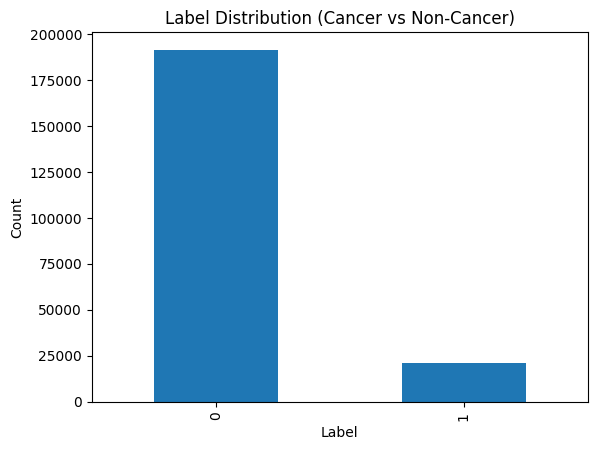

In [ ]:
df["label"].value_counts().plot(kind='bar')
plt.title("Label Distribution (Cancer vs Non-Cancer)")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

**2. Histogram (Age Distribution)**

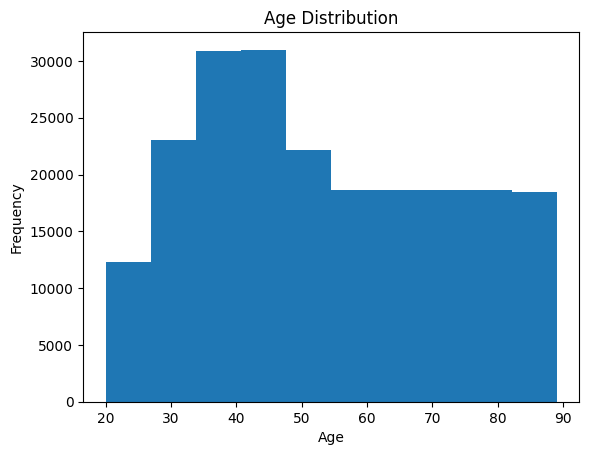

In [ ]:
df["age"].plot(kind='hist')
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

**Count Plot (Class Distribution)**


**This graph shows how many Cancer vs Non-Cancer cases are in your dataset.**

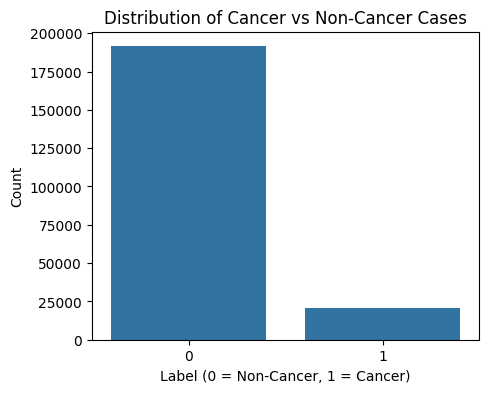

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))

sns.countplot(x="label", data=df)

plt.title("Distribution of Cancer vs Non-Cancer Cases")
plt.xlabel("Label (0 = Non-Cancer, 1 = Cancer)")
plt.ylabel("Count")

plt.show()

**Feature and Target Selection**

**This step separates input features (X) and target variable (Y) for model training.**

In [ ]:
X=df_encoded.drop("label", axis=1)
Y=df_encoded["label"]

**Importing Random Forest Model**

**This imports the Random Forest Classifier algorithm to build the machine learning model.**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

**Train-Test Split**

**This step separates input features (X) and target variable (Y) for model training.**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

**Model Training**

**This step trains the model using the training data.**

In [ ]:
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

## **Importing Evaluation Metrics, Prediction and Model Evaluation  **

**This imports functions to measure the performance of the model, uses the trained model to predict results on the test data and evaluates the model using accuracy, confusion matrix, and classification report. **bold text**

In [ ]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9006380824562643
Classification Report:
               precision    recall  f1-score   support

           0       0.90      1.00      0.95     38251
           1       0.00      0.00      0.00      4220

    accuracy                           0.90     42471
   macro avg       0.45      0.50      0.47     42471
weighted avg       0.81      0.90      0.85     42471



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


(None,)

## **Conclusion**

**This project successfully developed a machine learning model for gastric cancer detection using the Random Forest Classifier. The dataset was carefully preprocessed by handling missing values, removing duplicates, and converting categorical variables into numerical form through encoding. The model was trained and evaluated using appropriate techniques, including train-test splitting and performance metrics such as accuracy,and classification report. The results indicate that the Random Forest model provides reliable and accurate predictions for identifying cancer cases. Additionally, feature importance analysis highlights the key factors influencing the prediction. Overall, this model can be a useful tool in supporting early detection and decision-making in the healthcare domain.**